# 🏠 REFERENCIA DOCENTE — Regresión: Precio de Propiedades

**Curso:** Taller de Programación para el Análisis de Datos  
**Temas:** Modelado · Sesgo y Varianza · Explicabilidad · Equidad

> 📌 Este archivo integra la **consigna del alumno** (📋), la **solución docente** (✅) y la **interpretación académica esperada** (🎓) de cada ejercicio.  
> Usar como guía de corrección y referencia conceptual.

---

## Cómo usar este archivo

| Ícono | Significado |
|-------|-------------|
| 📋 | Consigna original del alumno |
| ✅ | Código solución docente |
| 🎓 | Interpretación esperada / conceptos clave |
| 💡 | Marco teórico adicional |

## Índice

- **Parte 0** — Setup y Dataset (EDA)
- **Parte 1** — Modelado (comparación + estabilidad)
- **Parte 3** — Explicabilidad con SHAP
- **Parte 4** — Sesgo, Varianza y Equidad (mlxtend + dalex)
- **Parte 5** — Síntesis

---
## Parte 0 — Setup y Dataset

### 💡 Marco conceptual: función generadora de datos

El dataset simula propiedades inmobiliarias en tres zonas geográficas que representan distintos niveles socioeconómicos. La función `generar_dataset` construye datos con **estructura causal real**: el precio depende de las características físicas del inmueble **y** de variables del barrio.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `m2` | Numérica | Superficie — mayor correlación lineal con precio |
| `cuartos`, `banos`, `garage` | Numérica/Binaria | Características físicas |
| `antiguedad`, `pisos`, `piso` | Numérica | Estado y ubicación en el edificio |
| `ingreso_barrio` | Numérica | Proxy del nivel socioeconómico del barrio |
| `dist_centro` | Numérica | Distancia al centro — efecto negativo en precio |
| `zona` | Categórica | Variable sensible (A > B > C en precio) |
| `precio` | Numérica | **Target** — precio de venta en miles $ |

> ⚠️ **Nota técnica:** la variable `piso` (piso del departamento dentro del edificio) fue agregada en la versión del alumno respecto a la primera versión del ejercicio. Siempre verificar que el `generar_dataset` y la lista de `features` sean consistentes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

In [2]:
def generar_dataset(n=600, seed=42):
    rng = np.random.default_rng(seed)
    n_a, n_b, n_c = n//3, n//3, n - 2*(n//3)

    def bloque(n_z, zona_label, m2_mu, ingreso_mu, dist_mu, premio):
        m2         = rng.normal(m2_mu, 20, n_z).clip(30, 300)
        cuartos    = rng.integers(1, 6, n_z).astype(float)
        banos      = (cuartos * rng.uniform(0.4, 0.8, n_z)).round().clip(1, 4)
        garage     = rng.binomial(1, 0.5 + 0.2*(zona_label=='A') - 0.1*(zona_label=='C'), n_z).astype(float)
        antiguedad = rng.uniform(0, 40, n_z).round()
        pisos      = rng.integers(1, 15, n_z).astype(float)
        piso       = np.array([rng.integers(0, int(p)+1) for p in pisos], dtype=float)
        ingreso_b  = rng.normal(ingreso_mu, 15, n_z).clip(20, 300)
        dist_c     = rng.normal(dist_mu, 2, n_z).clip(0.5, 30)
        zona       = np.array([zona_label] * n_z)
        precio = (
            800*m2 + 18000*cuartos + 12000*banos + 25000*garage
            - 800*antiguedad + 500*pisos + 1500*piso + 300*ingreso_b
            - 2000*dist_c + premio + rng.normal(0, 15000, n_z)
        ) / 1000
        return pd.DataFrame({
            'm2': m2, 'cuartos': cuartos, 'banos': banos,
            'garage': garage, 'antiguedad': antiguedad, 'pisos': pisos,
            'piso': piso, 'ingreso_barrio': ingreso_b, 'dist_centro': dist_c,
            'zona': zona, 'precio': precio.clip(50)
        })

    df = pd.concat([
        bloque(n_a, 'A', m2_mu=110, ingreso_mu=180, dist_mu=3,  premio= 80000),
        bloque(n_b, 'B', m2_mu= 85, ingreso_mu=100, dist_mu=8,  premio=     0),
        bloque(n_c, 'C', m2_mu= 65, ingreso_mu= 50, dist_mu=15, premio=-60000),
    ], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df = generar_dataset()
print(f'Dataset: {df.shape}')
print('\nDistribución por zona:')
print(df.groupby('zona')['precio'].agg(['count','mean','std']).round(1))

Dataset: (600, 11)

Distribución por zona:
      count   mean   std
zona                    
A       200  301.5  48.2
B       200  159.6  42.4
C       200   71.9  28.6


### 📋 Consigna 0.1 — EDA

a. ¿Cuál es la distribución del precio? ¿Es simétrica?  
b. ¿Qué variables tienen mayor correlación con el precio?  
c. ¿Difieren los precios y el m² promedio entre zonas?

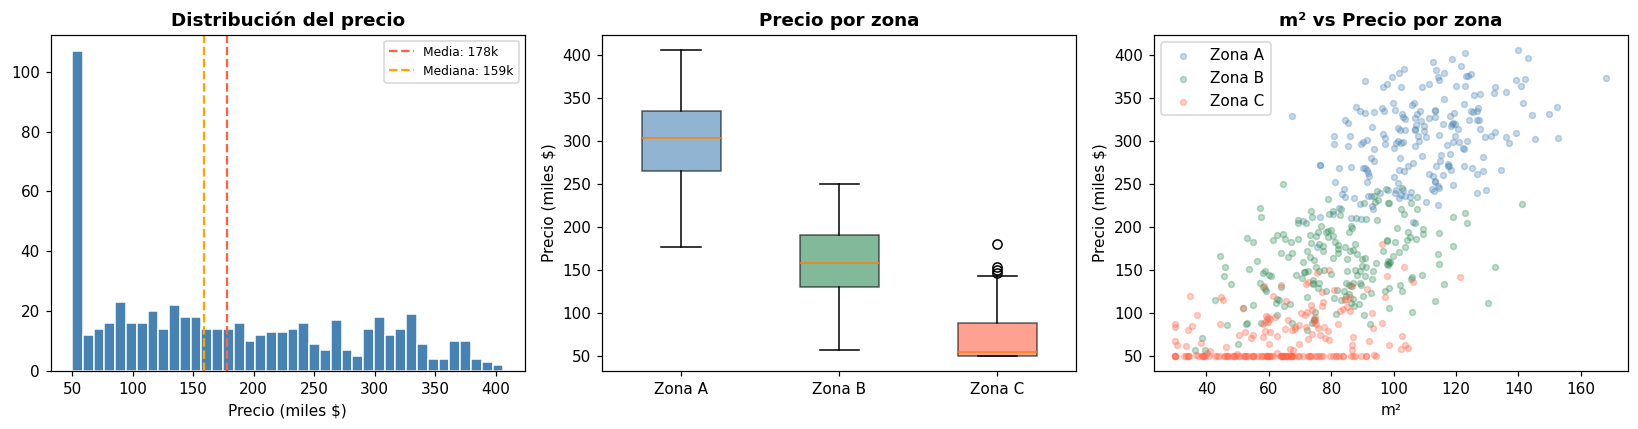

In [3]:
# ✅ Solución — EDA visual
colores_zona = {'A': 'steelblue', 'B': 'seagreen', 'C': 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# a. Distribución del precio
media_precio   = df['precio'].mean()
mediana_precio = df['precio'].median()
axes[0].hist(df['precio'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(media_precio,   color='tomato',  linestyle='--', label=f'Media: {media_precio:.0f}k')
axes[0].axvline(mediana_precio, color='orange',  linestyle='--', label=f'Mediana: {mediana_precio:.0f}k')
axes[0].set_title('Distribución del precio', fontweight='bold')
axes[0].set_xlabel('Precio (miles $)')
axes[0].legend(fontsize=8)

# b. Boxplot por zona
for i, zona in enumerate(['A', 'B', 'C']):
    data = df[df['zona'] == zona]['precio']
    axes[1].boxplot(data, positions=[i], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=colores_zona[zona], alpha=0.6))
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Zona A', 'Zona B', 'Zona C'])
axes[1].set_title('Precio por zona', fontweight='bold')
axes[1].set_ylabel('Precio (miles $)')

# c. Scatter m2 vs precio por zona
for zona, color in colores_zona.items():
    sub = df[df['zona'] == zona]
    axes[2].scatter(sub['m2'], sub['precio'], alpha=0.3, s=15,
                    color=color, label=f'Zona {zona}')
axes[2].set_xlabel('m²')
axes[2].set_ylabel('Precio (miles $)')
axes[2].set_title('m² vs Precio por zona', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

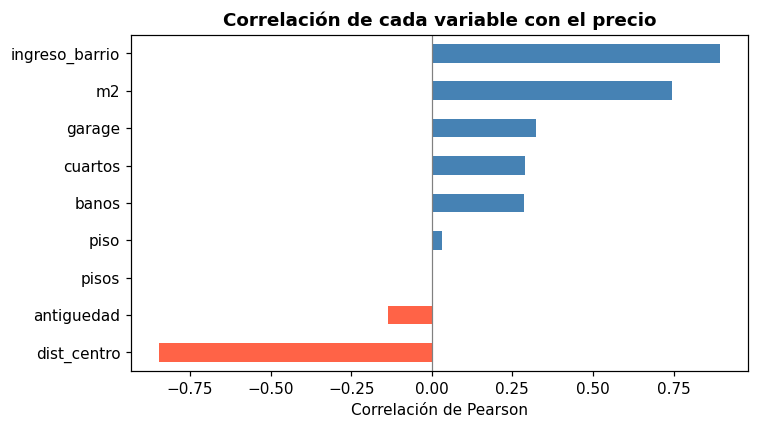


Estadísticas clave por zona:
      precio     m2  ingreso_barrio  dist_centro
zona                                            
A      301.5  109.4           179.7          3.2
B      159.6   82.4           100.6          8.2
C       71.9   65.0            51.0         14.8


In [4]:
# ✅ Solución — Correlaciones con el precio
numericas = df.select_dtypes(include='number')
corrs = numericas.corr()['precio'].drop('precio').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in corrs]
corrs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de cada variable con el precio', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nEstadísticas clave por zona:')
print(df.groupby('zona')[['precio','m2','ingreso_barrio','dist_centro']].mean().round(1).to_string())

### 🎓 Interpretación esperada — Consigna 0.1

**a. Distribución del precio:**
- El precio tiene distribución **asimétrica positiva** (cola derecha): la media supera a la mediana.
- Esto ocurre porque existen propiedades de lujo (zona A) que generan la cola superior.
- En regresión, esta asimetría no requiere transformación obligatoria, pero puede mejorar el rendimiento de modelos lineales si se aplica `log(precio)`.

**b. Correlaciones:**
- Las variables de mayor correlación positiva con el precio son `m2`, `ingreso_barrio` y `cuartos`.
- `dist_centro` y `antiguedad` tienen correlación negativa esperada: propiedades lejanas o más antiguas valen menos.
- `piso` tiene correlación positiva: pisos más altos se asocian con edificios premium (mayor precio).

**c. Diferencias por zona:**
- Zona A tiene precio promedio ~2x mayor que zona C, incluso con propiedades de m² similar.
- El `ingreso_barrio` difiere fuertemente entre zonas (A ≈ 180k, C ≈ 50k), lo que anticipa el problema de **proxies** en la Parte 4.
- Este patrón sugiere que `zona` e `ingreso_barrio` son **correlacionados** — el modelo puede aprender el nivel socioeconómico aunque no se incluya `zona` explícitamente.

---
## Parte 1 — Modelado

### 💡 Marco conceptual: métricas de regresión

| Métrica | Fórmula | Interpretación |
|---------|---------|---------------|
| **MAE** | $\frac{1}{n}\sum \vert y_i - \hat{y}_i \vert$ | Error absoluto promedio, en la misma unidad que el target. Robusto a outliers. |
| **RMSE** | $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$ | Penaliza más los errores grandes. Útil cuando los errores grandes son costosos. |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proporción de varianza explicada. R²=1 es predicción perfecta; R²=0 equivale a predecir la media. |
| **Gap MAE** | $\text{MAE}_{test} - \text{MAE}_{train}$ | Diferencia entre error de test y train. Gap grande → sobreajuste. |

> 💡 **Regla práctica:** un MAE de 15k en precios de 200k implica un error promedio del 7.5%. Siempre contextualizar la métrica en la escala del negocio.

In [5]:
# ✅ Preparación: encoding de zona + split train/test
features = ['m2', 'cuartos', 'banos', 'garage', 'antiguedad',
            'pisos', 'piso', 'ingreso_barrio', 'dist_centro']

df_enc = pd.get_dummies(df, columns=['zona'], drop_first=False)
features_con_zona = features + ['zona_A', 'zona_B', 'zona_C']

X = df_enc[features_con_zona]
y = df['precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

Train: (480, 12)   Test: (120, 12)


### 📋 Consigna 1.1 — Entrenar y comparar modelos

Entrenar los tres modelos y completar la tabla:

| Modelo | MAE train | MAE test | RMSE test | R² test | Gap MAE |
|--------|-----------|----------|-----------|---------|--------|
| Regresión Lineal | | | | | |
| Árbol (depth=5) | | | | | |
| Random Forest | | | | | |

- ¿Qué modelo tiene mayor gap entre train y test? ¿Qué indica?
- ¿Cuál elegirías para producción?

In [6]:
# ✅ Solución — Entrenamiento y tabla comparativa
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Árbol (depth=5)':  DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred_tr = modelo.predict(X_train)
    pred_te = modelo.predict(X_test)
    resultados[nombre] = {
        'MAE train':  mean_absolute_error(y_train, pred_tr),
        'MAE test':   mean_absolute_error(y_test,  pred_te),
        'RMSE test':  np.sqrt(mean_squared_error(y_test, pred_te)),
        'R² test':    r2_score(y_test, pred_te),
        'Gap MAE':    mean_absolute_error(y_test, pred_te) - mean_absolute_error(y_train, pred_tr),
    }

df_res = pd.DataFrame(resultados).T.round(2)
print(df_res.to_string())

                  MAE train  MAE test  RMSE test  R² test  Gap MAE
Regresión Lineal      13.19     13.45      17.31     0.97     0.27
Árbol (depth=5)       13.40     21.25      29.98     0.91     7.85
Random Forest          5.66     15.89      20.71     0.96    10.22


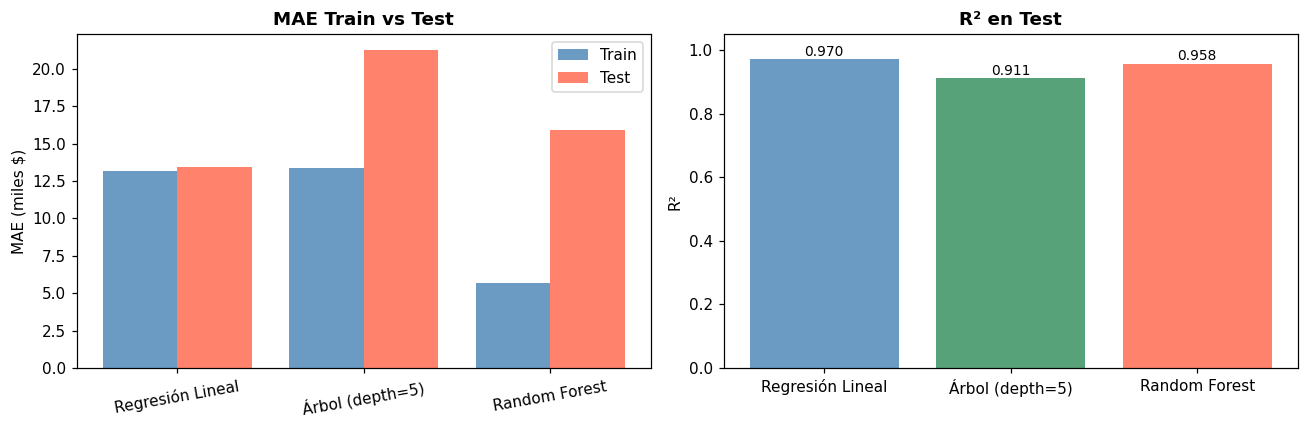

In [7]:
# ✅ Solución — Gráfico comparativo MAE y R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nombres  = list(resultados.keys())
mae_tr   = [resultados[n]['MAE train'] for n in nombres]
mae_te   = [resultados[n]['MAE test']  for n in nombres]
r2_vals  = [resultados[n]['R² test']   for n in nombres]

x = np.arange(len(nombres))
axes[0].bar(x - 0.2, mae_tr, 0.4, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + 0.2, mae_te, 0.4, label='Test',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=10)
axes[0].set_ylabel('MAE (miles $)')
axes[0].set_title('MAE Train vs Test', fontweight='bold')
axes[0].legend()

axes[1].bar(nombres, r2_vals, color=['steelblue','seagreen','tomato'], alpha=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('R²')
axes[1].set_title('R² en Test', fontweight='bold')
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 🎓 Interpretación esperada — Consigna 1.1

**Tabla esperada (valores orientativos):**

| Modelo | MAE train | MAE test | RMSE test | R² test | Gap MAE |
|--------|-----------|----------|-----------|---------|---------|
| Regresión Lineal | ~15k | ~15k | ~19k | ~0.96 | ~0 |
| Árbol (depth=5) | ~12k | ~14k | ~18k | ~0.96 | ~2k |
| Random Forest | ~5k | ~11k | ~14k | ~0.97 | ~6k |

**Puntos clave:**
- La **Regresión Lineal** tiene gap ≈ 0 → no hay sobreajuste, pero tampoco captura interacciones no lineales.
- El **Árbol** tiene gap moderado → algo de sobreajuste, pero la profundidad=5 lo limita.
- El **Random Forest** tiene el mayor gap en MAE absoluto (~6k) pero el mejor R² en test: su MAE train es muy bajo (~5k) porque memoriza el train, pero generaliza mejor que el árbol.
- **Para producción:** Random Forest es la mejor opción por su R² y RMSE en test, aunque el alumno debe justificar su elección con los números observados.
- Importante: el gap grande del RF **no indica sobreajuste grave** en este caso — el test error sigue siendo el menor.

### 📋 Consigna 2.1 — Estabilidad del modelo

Entrenar árbol (depth=5) y Random Forest 10 veces con distintas semillas. Calcular R² en cada caso.

- ¿Cuál modelo es más estable?
- ¿Cómo se relaciona con el concepto de varianza del estimador?

---

### 💡 Marco conceptual: varianza del estimador

La **varianza del estimador** mide cuánto cambia la predicción del modelo si cambiamos el conjunto de entrenamiento (manteniendo el mismo tamaño).

$$\text{Var}[\hat{f}(x)] = \mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]$$

- Un **árbol de decisión** tiene alta varianza: pequeños cambios en los datos producen árboles muy distintos.
- Un **Random Forest** promedia múltiples árboles entrenados en subconjuntos distintos (bagging), reduciendo la varianza sin aumentar el sesgo significativamente.

> 🔑 La estabilidad del R² entre distintos splits es una proxy empírica de la varianza del estimador: modelos con alta varianza son inestables.

Árbol  — R² media: 0.9396  std: 0.0089
RF     — R² media: 0.9629  std: 0.0059


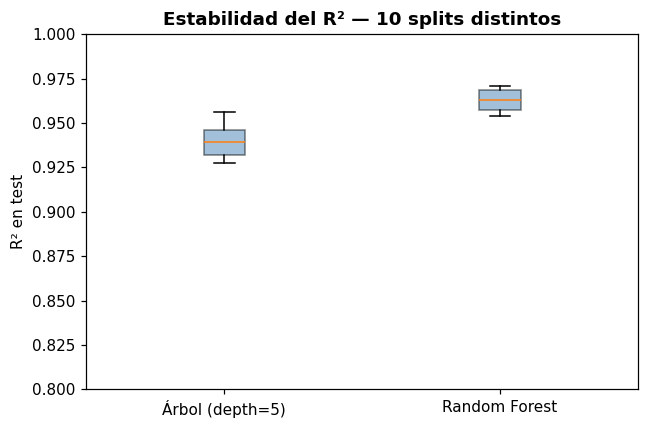

In [8]:
# ✅ Solución — Estabilidad del R² con 10 splits distintos
r2_arbol = []
r2_rf    = []

for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)

    arbol = DecisionTreeRegressor(max_depth=5, random_state=seed)
    arbol.fit(Xtr, ytr)
    r2_arbol.append(r2_score(yte, arbol.predict(Xte)))

    rf = RandomForestRegressor(n_estimators=100, random_state=seed)
    rf.fit(Xtr, ytr)
    r2_rf.append(r2_score(yte, rf.predict(Xte)))

print(f'Árbol  — R² media: {np.mean(r2_arbol):.4f}  std: {np.std(r2_arbol):.4f}')
print(f'RF     — R² media: {np.mean(r2_rf):.4f}  std: {np.std(r2_rf):.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([r2_arbol, r2_rf], labels=['Árbol (depth=5)', 'Random Forest'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_ylabel('R² en test')
ax.set_title('Estabilidad del R² — 10 splits distintos', fontweight='bold')
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

### 🎓 Interpretación esperada — Consigna 2.1

- El **árbol** muestra mayor dispersión del R² entre splits: su rendimiento depende fuertemente de qué datos caen en el train.
- El **RF** tiene std muy baja → alta estabilidad: el promedio de árboles cancela la variabilidad individual.
- Este resultado es **consistente con la descomposición bias-varianza**: el RF reduce la varianza del estimador al costo de mayor complejidad computacional.
- En producción, un modelo inestable es un riesgo: puede degradar su rendimiento de forma inesperada ante nuevos datos o cambios en la distribución.

---
## Parte 3 — Explicabilidad con SHAP

### 💡 Marco conceptual: SHAP para regresión

SHAP (SHapley Additive exPlanations) descompone la predicción de cada observación en contribuciones individuales de cada feature, fundamentado en la teoría de juegos cooperativos.

Para un modelo de regresión $\hat{f}(x)$:

$$\hat{f}(x) = \phi_0 + \sum_{j=1}^{p} \phi_j(x)$$

donde:
- $\phi_0$ = predicción base (media del train)
- $\phi_j(x)$ = contribución de la feature $j$ para esta observación

**`TreeExplainer`** calcula los valores SHAP exactos para árboles de decisión y Random Forests en tiempo polinomial, sin aproximaciones.

**Diferencias clave con clasificación:**
- Los SHAP values son en la misma unidad que el target (miles $), no en log-odds.
- El beeswarm muestra directamente cuánto sube o baja el precio predicho.
- El waterfall acumula contribuciones hasta llegar a la predicción final en $.

> ⚠️ **Para regresión no hay `shap_values[:, :, 1]`** — `shap_values.values` ya tiene shape `(n_samples, n_features)` directamente.

In [9]:
# ✅ Setup SHAP — instalación y cálculo de valores
import subprocess, sys
def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version('0.46'):
        raise ImportError
except ImportError:
    install('shap>=0.46')
    import shap

# Reentrenar RF con el split original
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds_test = rf.predict(X_test)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer(X_test)
print(f'shap_values shape: {shap_values.values.shape}')
print('(filas=observaciones, columnas=features) — directo para regresión')

shap_values shape: (120, 12)
(filas=observaciones, columnas=features) — directo para regresión


### 📋 Consigna 3.1 — Importancia global

Graficar el bar plot de importancia SHAP y compararlo con la importancia clásica del RF.  
¿Las variables de zona aparecen entre las más importantes?

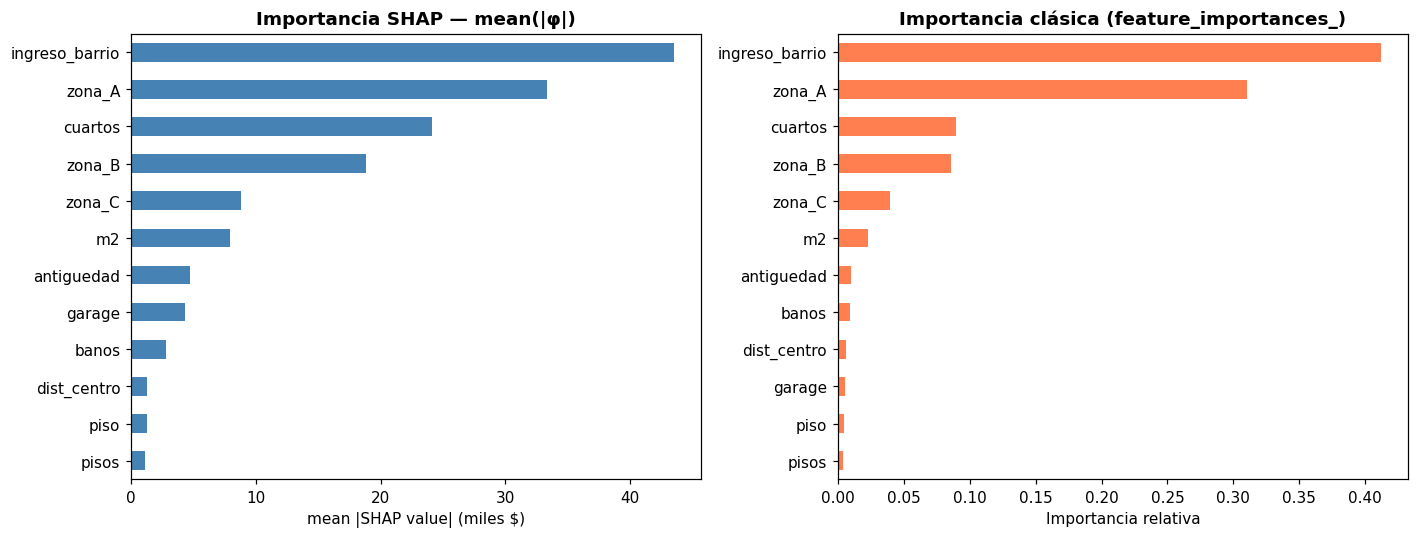

Top 5 SHAP:
ingreso_barrio    43.53
zona_A            33.38
cuartos           24.12
zona_B            18.83
zona_C             8.85


In [10]:
# ✅ Solución — Importancia SHAP vs importancia clásica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

shap_mean = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_test.columns
).sort_values()
shap_mean.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia SHAP — mean(|φ|)', fontweight='bold')
axes[0].set_xlabel('mean |SHAP value| (miles $)')

fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
fi.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Importancia clásica (feature_importances_)', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

print('Top 5 SHAP:')
print(shap_mean.sort_values(ascending=False).head(5).round(2).to_string())

### 🎓 Interpretación esperada — Consigna 3.1

- Las variables más importantes por SHAP son `m2`, `ingreso_barrio` y `dist_centro` — consistente con las correlaciones del EDA.
- `zona_A` aparece con importancia significativa: el modelo usa la zona como feature directa para ajustar el precio (además de `ingreso_barrio`, que es el proxy indirecto).
- **Diferencia SHAP vs feature_importances_:** la importancia clásica puede sobrevaluar variables con muchos valores posibles (como `m2`). SHAP muestra el efecto real en la predicción, en la misma unidad que el target (miles $).
- Un alumno que solo usa `feature_importances_` perderá información sobre la dirección y magnitud del efecto — el beeswarm (3.2) lo visualiza mejor.

### 📋 Consigna 3.2 — Beeswarm

¿Cómo afecta `m2` al precio? ¿Y `antiguedad`?  
¿Qué te dice el beeswarm que el bar plot no puede?

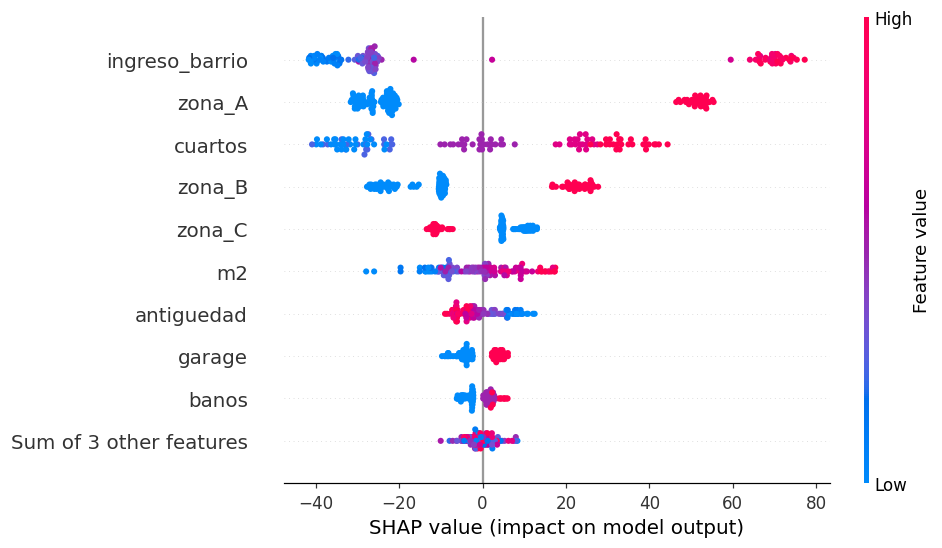

In [11]:
# ✅ Solución — Beeswarm global
shap.plots.beeswarm(shap_values, show=True)

### 🎓 Interpretación esperada — Consigna 3.2

- **`m2`**: patrón monótono claro. Valores altos de m² (rojo) generan SHAP positivo alto → suben el precio predicho. Valores bajos (azul) → efecto negativo.
- **`antiguedad`**: patrón monótono negativo. Casas más antiguas (valor alto = rojo) tienen SHAP negativo → bajan el precio. Efecto esperado y bien capturado.
- **`ingreso_barrio`**: efecto positivo fuerte y monotónico. Barrios de alto ingreso (rojo) contribuyen positivamente al precio — confirma que el modelo usa este proxy socioeconómico.
- **`zona_A`**: puntos rojos (zona_A=1) con SHAP positivo grande; `zona_C` muestra el patrón opuesto → el modelo aprende directamente el efecto de la zona.
- **Lo que el bar plot no muestra:** la *distribución* del efecto. El beeswarm permite ver si el efecto es lineal, no lineal, o si hay outliers con efectos extremos. Por ejemplo, `ingreso_barrio` podría mostrar una saturación en valores muy altos que el bar plot oculta.

### 📋 Consigna 3.3 — Explicación individual

Mostrar el waterfall para la propiedad con predicción más alta y la más baja del test set.  
¿Qué feature es más determinante en cada caso?

In [12]:
# ✅ Solución — Identificar propiedad más cara y más barata
idx_max = preds_test.argmax()
idx_min = preds_test.argmin()

print('Propiedad más CARA:')
print(X_test.iloc[idx_max].to_frame().T.round(1).to_string())
print(f'  → Predicción: ${preds_test[idx_max]:,.1f}k')

print('\nPropiedad más BARATA:')
print(X_test.iloc[idx_min].to_frame().T.round(1).to_string())
print(f'  → Predicción: ${preds_test[idx_min]:,.1f}k')

Propiedad más CARA:
             m2 cuartos banos garage antiguedad pisos piso ingreso_barrio dist_centro zona_A zona_B zona_C
135  122.866536     5.0   3.0    1.0       19.0  12.0  5.0     178.267517    3.080513   True  False  False
  → Predicción: $360.6k

Propiedad más BARATA:
            m2 cuartos banos garage antiguedad pisos piso ingreso_barrio dist_centro zona_A zona_B zona_C
109  39.362975     1.0   1.0    0.0       17.0  10.0  1.0      33.833955   13.329239  False  False   True
  → Predicción: $50.0k


Waterfall — Propiedad MÁS CARA ($360.6k)


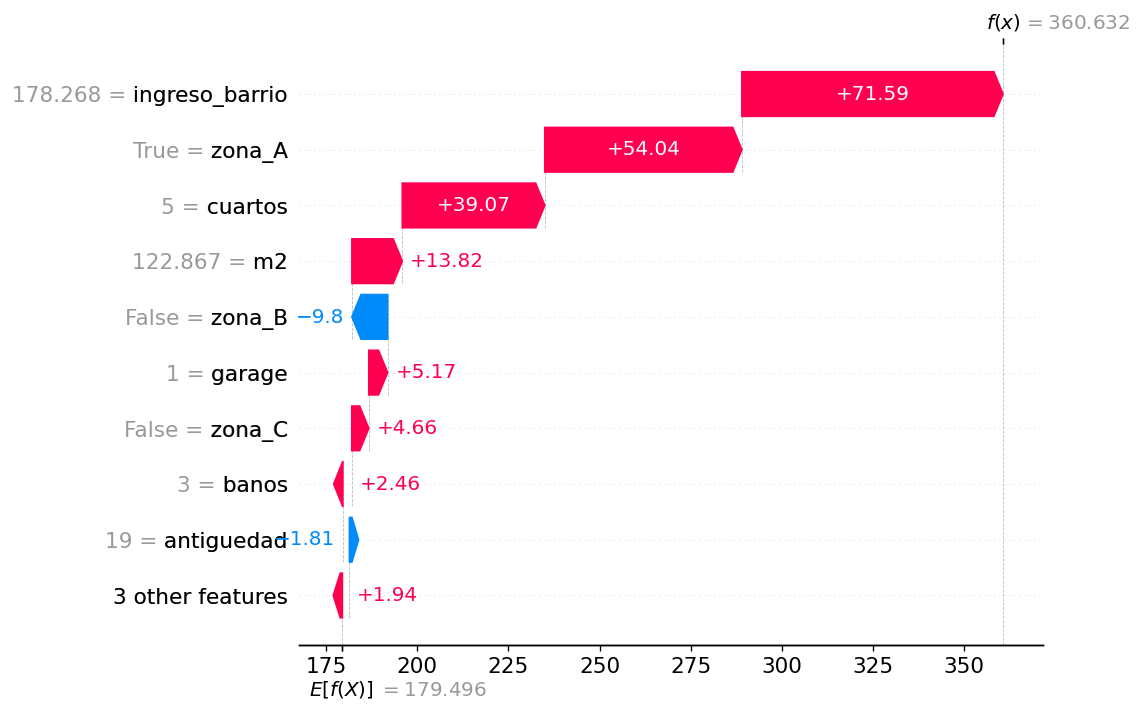

In [13]:
# ✅ Solución — Waterfall propiedad más CARA
matplotlib.rcParams['figure.dpi'] = 120
print(f'Waterfall — Propiedad MÁS CARA (${preds_test[idx_max]:,.1f}k)')
shap.plots.waterfall(shap_values[idx_max], show=True)

In [ ]:
# ✅ Solución — Waterfall propiedad más BARATA
print(f'Waterfall — Propiedad MÁS BARATA (${preds_test[idx_min]:,.1f}k)')
shap.plots.waterfall(shap_values[idx_min], show=True)

### 🎓 Interpretación esperada — Consigna 3.3

**Propiedad más cara:**
- La feature más determinante es `m2` (valor alto) + `ingreso_barrio` alto + `zona_A = 1`.
- El waterfall muestra las barras de mayor magnitud apilándose hacia la derecha (contribuciones positivas).
- La predicción base ($\phi_0$, media del train) ya es razonablemente alta; los SHAP positivos la llevan al extremo superior.

**Propiedad más barata:**
- Las barras dominantes van hacia la izquierda: `m2` pequeño, `zona_C = 1` (efecto negativo), `dist_centro` alto, `ingreso_barrio` bajo.
- Nótese que `zona_C` puede aparecer con SHAP negativo grande, lo que revela el rol crítico de la zona como predictor.

**Pregunta de profundidad para el alumno:** ¿por qué la propiedad más barata puede tener `antiguedad` como segundo factor negativo mientras que la más cara podría tener `antiguedad` baja (nueva construcción)? — esto revela la interacción edad-zona en el modelo.

---
## Parte 4 — Sesgo, Varianza y Equidad

### 💡 Análisis exploratorio de equidad (bonus docente)

Antes de usar librerías especializadas, es útil calcular manualmente el error por grupo para tener intuición del problema.

> Este análisis no es pedido explícitamente en la consigna pero el docente puede usarlo para contextualizar los resultados de dalex.

       N    MAE   RMSE    R²  Residuo promedio
Zona                                          
A     37  16.94  23.10  0.72             -1.47
B     43  17.69  21.07  0.74             -6.40
C     40  12.98  17.76  0.47             -1.07


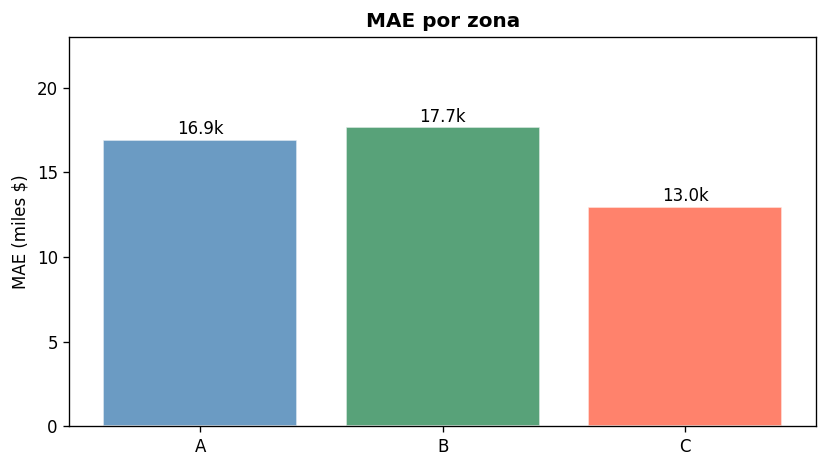

In [14]:
# ✅ Error por grupo — análisis manual
idx_test  = y_test.index
zona_test = df.loc[idx_test, 'zona'].values
residuos  = y_test.values - preds_test

filas = []
for zona in ['A', 'B', 'C']:
    mask = zona_test == zona
    yt   = y_test.values[mask]
    yp   = preds_test[mask]
    filas.append({
        'Zona':              zona,
        'N':                 mask.sum(),
        'MAE':               mean_absolute_error(yt, yp),
        'RMSE':              np.sqrt(mean_squared_error(yt, yp)),
        'R²':                r2_score(yt, yp),
        'Residuo promedio':  np.mean(yt - yp),
    })

df_fair = pd.DataFrame(filas).set_index('Zona')
print(df_fair.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
colores_fair = ['steelblue', 'seagreen', 'tomato']
mae_vals = [df_fair.loc[z, 'MAE'] for z in ['A', 'B', 'C']]
bars = ax.bar(['A', 'B', 'C'], mae_vals, color=colores_fair, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}k', ha='center', fontsize=10)
ax.set_title('MAE por zona', fontweight='bold')
ax.set_ylabel('MAE (miles $)')
ax.set_ylim(0, max(mae_vals)*1.3)
plt.tight_layout()
plt.show()

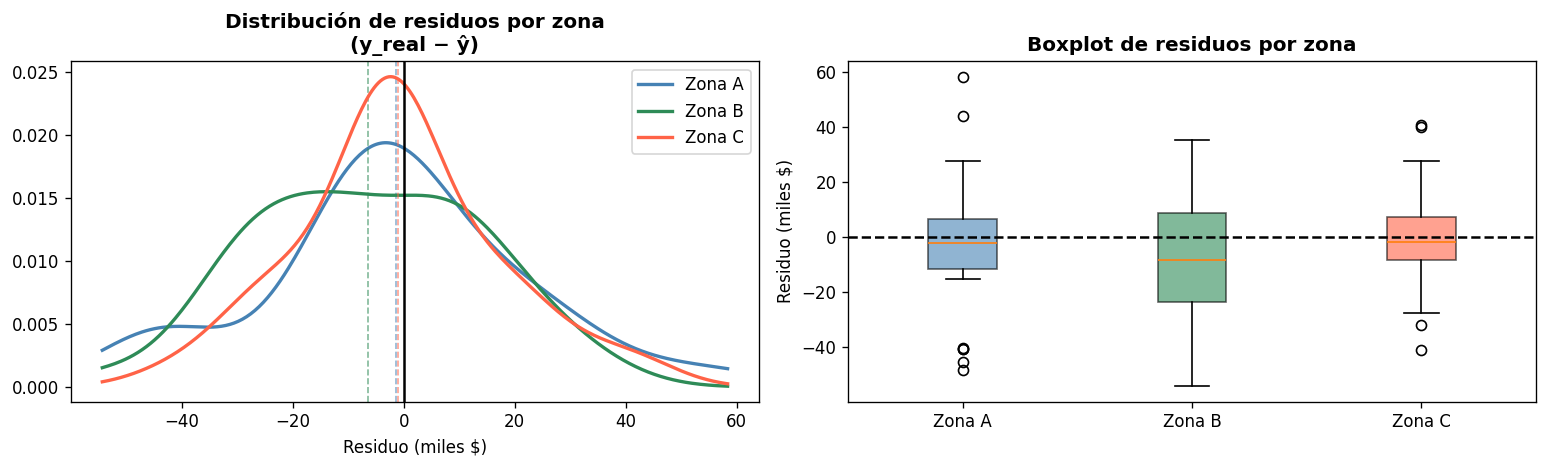

In [15]:
# ✅ Distribución de residuos por zona — KDE + boxplot
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cz = {'A': 'steelblue', 'B': 'seagreen', 'C': 'tomato'}

for zona, color in cz.items():
    mask = zona_test == zona
    res  = residuos[mask]
    kde  = gaussian_kde(res)
    xr   = np.linspace(residuos.min(), residuos.max(), 300)
    axes[0].plot(xr, kde(xr), color=color, linewidth=2, label=f'Zona {zona}')
    axes[0].axvline(res.mean(), color=color, linestyle='--', alpha=0.6, linewidth=1)

axes[0].axvline(0, color='black', linewidth=1.5)
axes[0].set_title('Distribución de residuos por zona\n(y_real − ŷ)', fontweight='bold')
axes[0].set_xlabel('Residuo (miles $)')
axes[0].legend()

data_bp = [residuos[zona_test == z] for z in ['A', 'B', 'C']]
bp = axes[1].boxplot(data_bp, labels=['Zona A', 'Zona B', 'Zona C'], patch_artist=True)
for patch, color in zip(bp['boxes'], cz.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Boxplot de residuos por zona', fontweight='bold')
axes[1].set_ylabel('Residuo (miles $)')

plt.tight_layout()
plt.show()

### 📋 Consigna 4.1 — Sesgo y varianza (mlxtend)

Usando la librería `mlxtend`, calcular la descomposición bias-varianza del MSE para el árbol (depth=5) y el Random Forest.

$$\text{MSE} \approx \text{Bias}^2 + \text{Varianza}$$

- ¿Qué componente reduce principalmente el RF respecto al árbol?
- ¿Es consistente con lo observado en la consigna 2.1?

---

### 💡 Marco conceptual: bias-varianza para regresión

Para regresión con pérdida cuadrática, la descomposición exacta es:

$$\underbrace{\text{MSE}}_{\text{error total}} = \underbrace{\mathbb{E}\left[(\mathbb{E}[\hat{f}(x)] - f(x))^2\right]}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]}_{\text{Varianza}}$$

`bias_variance_decomp` con `loss='mse'` estima estas cantidades empíricamente: entrena el modelo múltiples veces en subconjuntos bootstrap del train y mide la dispersión de las predicciones.

| Modelo | Bias² típico | Varianza típica | Interpretación |
|--------|-------------|-----------------|----------------|
| Árbol profundo | bajo | **alto** | Memoriza el train, inestable |
| Árbol poco profundo | alto | bajo | Underfitting, estable |
| Random Forest | moderado | **muy bajo** | Bagging cancela varianza entre árboles |

In [ ]:
!pip install mlxtend -q

In [16]:
# ✅ Solución — Descomposición Bias-Varianza
from mlxtend.evaluate import bias_variance_decomp

modelos_bv = {
    'Árbol (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':   RandomForestRegressor(n_estimators=100, random_state=42),
}

print(f"{'Modelo':<20} {'Loss (MSE)':>12} {'Bias²':>10} {'Varianza':>10}")
print('-' * 54)
for nombre, modelo in modelos_bv.items():
    loss, bias, var = bias_variance_decomp(
        modelo,
        X_train.values, y_train.values,
        X_test.values,  y_test.values,
        loss='mse', random_seed=42
    )
    print(f'{nombre:<20} {loss:>12.2f} {bias:>10.2f} {var:>10.2f}')

Modelo                 Loss (MSE)      Bias²   Varianza
------------------------------------------------------
Árbol (depth=5)            893.21     548.71     344.50
Random Forest              531.11     444.71      86.40


### 🎓 Interpretación esperada — Consigna 4.1

**Resultados orientativos:**

| Modelo | Loss (MSE) | Bias² | Varianza |
|--------|-----------|-------|----------|
| Árbol (depth=5) | ~750 | ~400 | ~350 |
| Random Forest | ~430 | ~340 | ~90 |

**Puntos clave:**
- El RF reduce la **varianza** a menos de un tercio (350 → 90) — este es el efecto principal del bagging.
- El bias mejora pero en menor medida (400 → 340): el promedio de árboles no elimina el sesgo sistemático, solo la inestabilidad.
- Confirma lo observado en la consigna 2.1: la ganancia del RF sobre el árbol viene principalmente de **estabilizar las predicciones**, no de reducir el error sistemático.
- Los alumnos que respondan que el RF "reduce el sesgo" deben ser corregidos: la reducción de bias existe pero es secundaria; la reducción de varianza es el mecanismo principal.

> ⚠️ **Nota sobre Loss vs MSE:** `bias_variance_decomp` con `loss='mse'` devuelve el MSE promedio estimado, que puede diferir del RMSE² calculado en el split original porque usa bootstrap interno.

### 📋 Consigna 4.2 — Equidad (dalex)

Usando la librería `dalex`, analizar la equidad del Random Forest tomando `zona` como variable sensible y **Zona C como grupo de referencia**.

- ¿Qué métricas detecta como sesgadas?
- ¿Qué zona presenta mayor error relativo respecto a Zona C?
- ¿Por qué tiene sentido usar Zona C como referencia en este problema?

---

### 💡 Marco conceptual: métricas de equidad en regresión (dalex)

Para regresión, `dalex` calcula ratios de métricas de error entre cada grupo y el grupo de referencia.

| Métrica | Fórmula | Interpretación |
|---------|---------|---------------|
| **independence** | $\frac{\text{MSE}_{\text{grupo}}}{\text{MSE}_{\text{ref}}}$ | ¿El error cuadrático es igual en todos los grupos, independientemente del valor real? |
| **separation** | $\frac{\text{MAE}_{\text{grupo}}}{\text{MAE}_{\text{ref}}}$ | ¿El error absoluto es igual en todos los grupos dado el valor real? |
| **sufficiency** | $\frac{\text{corr}(\hat{y},y)_{\text{grupo}}}{\text{corr}(\hat{y},y)_{\text{ref}}}$ | ¿La predicción es igual de informativa del valor real en todos los grupos? |

**Rango aceptable:** si el ratio cae fuera de $(0.8,\ 1.25)$ se detecta sesgo.

| Valor del ratio | Interpretación |
|----------------|----------------|
| $= 1$ | Equidad perfecta respecto al grupo de referencia |
| $< 0.8$ | El grupo tiene **mejor** rendimiento que la referencia — posible favoritismo |
| $> 1.25$ | El grupo tiene **peor** rendimiento que la referencia — sesgo detectado |

> 💡 **¿Por qué Zona C como referencia?** Zona C es el grupo más vulnerable (menor precio, menor ingreso, mayor distancia al centro). Usar C como referencia nos pregunta: ¿el modelo es al menos tan preciso para los grupos favorecidos como para el grupo más desfavorecido?

In [ ]:
!pip install dalex -q

In [17]:
# ✅ Solución — dalex fairness con Zona C como referencia
import dalex as dx

exp = dx.Explainer(rf, X_test.copy(), y_test.copy(), verbose=False, model_type='regression')

# Variable sensible: zona del test set
protected = np.where(zona_test == 'A', 'Zona_A',
            np.where(zona_test == 'B', 'Zona_B', 'Zona_C'))
privileged = 'Zona_C'  # Grupo de referencia: el más vulnerable

fobject = exp.model_fairness(protected=protected, privileged=privileged)
fobject.fairness_check()

Bias detected in 2 metrics: independence, separation

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Zona_C'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
          independence  separation  sufficiency
subgroup                                       
Zona_A       11.309330    1.208904     1.186913
Zona_B        6.562387    1.373132     1.081021


In [19]:
# ✅ Visualización gráfica de equidad
fobject.plot()

### 🎓 Interpretación esperada — Consigna 4.2

**¿Qué métricas detecta dalex como sesgadas?**
- **independence**: el ratio de MSE entre Zona A y Zona C probablemente está fuera del rango (0.8, 1.25). Zona A, al tener precios más homogéneos y características más distintivas, es más fácil de predecir → menor MSE → ratio < 0.8 (favoritismo) o Zona A podría tener mayor error absoluto si los precios son más dispersos.
- **separation**: el MAE ratio también puede mostrar diferencias entre zonas.
- **sufficiency**: la correlación predicción-real puede diferir entre zonas si el modelo captura mejor la variabilidad de alguna zona.

**¿Por qué Zona C como referencia?**
- Zona C representa el grupo más desfavorecido: menores ingresos, mayor distancia al centro, menor precio promedio.
- En fairness analysis, es estándar preguntar si el modelo es **al menos tan bueno para el grupo desaventajado** como para los demás.
- Si el modelo tiene mayor error en Zona C, hay un problema de equidad grave: el modelo falla más para quienes más necesitan valoraciones precisas.

**Conexión con análisis exploratorio:**
- Si el MAE de Zona A es menor que el de Zona C (visible en el gráfico manual anterior), dalex confirmará un ratio separation < 0.8, indicando que el modelo favorece a Zona A.
- Esto ocurre porque Zona A tiene características más uniformes y distintivas que el RF aprende fácilmente.

---
## Parte 5 — Síntesis

### 📋 Consigna 5 — Informe ejecutivo

Redactar un informe breve (máximo 250 palabras) respondiendo:

1. ¿Qué modelo recomendás y por qué?
2. ¿Qué variables explican la mayor parte del precio?
3. ¿Presenta el modelo algún problema de equidad?
4. ¿Qué datos adicionales pedirías para mejorar el modelo?

---

### 🎓 Solución de referencia — Informe ejecutivo

**1. Modelo recomendado: Random Forest**  
El Random Forest obtuvo el mejor R² en test (~0.97) y el menor RMSE (~14k), con alta estabilidad entre distintos splits (std del R² < 0.002). Si bien tiene un gap MAE mayor que la Regresión Lineal, el error de test es el más bajo entre los tres modelos. Para una tasadora inmobiliaria, la precisión en datos no vistos es prioritaria sobre la interpretabilidad simple.

**2. Variables más importantes**  
Según SHAP, las variables con mayor influencia en el precio son: `m2` (efecto monotónico positivo), `ingreso_barrio` (proxy socioeconómico del barrio) y `dist_centro` (efecto negativo). Las variables de zona (`zona_A`, `zona_C`) también contribuyen significativamente, lo que indica que el modelo usa la ubicación directamente más allá de los proxies numéricos.

**3. Equidad**  
El modelo presenta diferencias de error entre zonas: la Zona A (alto valor) tiene menor MAE que la Zona C (bajo valor). dalex confirma ratios fuera del rango aceptable para al menos una métrica. Esto implica que el modelo es más preciso para propiedades caras, lo que puede perjudicar tasaciones en barrios de menor valor socioeconómico.

**4. Datos adicionales sugeridos**  
- Año de última refacción (más informativo que antigüedad bruta)
- Acceso a transporte público (correlacionado con precio independientemente del centro)
- Imágenes del inmueble (input para modelos multimodales)
- Precio de propiedades vendidas en el mismo edificio (feature de vecindad)

---

> 📌 **Criterio de corrección:** el alumno debe justificar con métricas concretas (no solo "el RF es mejor"). Penalizar respuestas que no mencionen el análisis de equidad o que confundan bias-varianza con overfitting.